<a href="https://colab.research.google.com/github/zosiawidawska/Pliki/blob/main/text_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP – Przetwarzanie tekstu do postaci numerycznej
### Normalizacja · Stemming · Lemmatyzacja · Bag of Words · TF-IDF

---

**Cel zajęć:** Nauczyć się przekształcać surowy tekst w reprezentację numeryczną gotową do użycia przez algorytmy uczenia maszynowego.

**Plan notebooka:**
1. Normalizacja tekstu
2. Stemming (NLTK)
3. Lemmatyzacja (spaCy)
4. Porównanie stemming vs. lemmatyzacja
5. Stop words
6. One-Hot Encoding
7. Bag of Words (BoW)
8. TF-IDF
9. Zadanie końcowe – pełny pipeline

## Instalacja i importy

In [ ]:
# Odkomentuj jeśli nie masz zainstalowanych bibliotek:
!pip install nltk spacy scikit-learn wordcloud matplotlib pandas numpy --quiet
!python -m spacy download en_core_web_md --quiet

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.stem import PorterStemmer, SnowballStemmer
nltk.download('stopwords', quiet=True)

import spacy
nlp = spacy.load('en_core_web_md')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print('Wszystko załadowane!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 57.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Wszystko załadowane!


---
## Część 1 – Normalizacja tekstu

**Normalizacja** to pierwszy krok w przetwarzaniu tekstu. Sprowadza różne formy zapisu do jednolitego formatu, dzięki czemu model traktuje `"Kot"`, `"KOT"` i `"kot"` jako to samo słowo.

Typowe kroki normalizacji:
- zamiana na małe litery
- usunięcie znaków interpunkcyjnych i specjalnych
- normalizacja spacji

### Zadanie 1.1 – Napisz funkcję `normalize()`

Napisz funkcję, która:
1. Zamienia wszystkie litery na małe
2. Usuwa znaki inne niż litery, cyfry i spacje (użyj `re.sub`)
3. Zamienia wiele spacji na jedną
4. Usuwa spacje z początku i końca tekstu

Oczekiwany wynik:
```
normalize("Kot gonił PSA! Szybko, bardzo szybko.")
→ 'kot gonił psa szybko bardzo szybko'
```

In [ ]:
import re

def normalize(text):
    text = text.lower()

    text = re.sub(r"[^a-ząćęłńóśźż0-9\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

# Test
test_cases = [
    ("Kot gonił PSA! Szybko, bardzo szybko.", "kot gonił psa szybko bardzo szybko"),
    ("Hello,   WORLD!!!", "hello world"),
    ("  Spacje   na   początku   i   końcu  ", "spacje na początku i końcu"),
]

for text, expected in test_cases:
    result = normalize(text)
    status = 'ok' if result == expected else 'nie ok'
    print(f'{status} Wejście: {repr(text)}')
    print(f' Wynik: {repr(result)}')
    print(f' Oczekiwany: {repr(expected)}')
    print()

ok Wejście: 'Kot gonił PSA! Szybko, bardzo szybko.'
 Wynik: 'kot gonił psa szybko bardzo szybko'
 Oczekiwany: 'kot gonił psa szybko bardzo szybko'

ok Wejście: 'Hello,   WORLD!!!'
 Wynik: 'hello world'
 Oczekiwany: 'hello world'

ok Wejście: '  Spacje   na   początku   i   końcu  '
 Wynik: 'spacje na początku i końcu'
 Oczekiwany: 'spacje na początku i końcu'



### Zadanie 1.2 – Eksperyment z normalizacją

Poniżej masz zdanie. Zastosuj `normalize()` i sprawdź:
- Ile unikalnych słów jest **przed** normalizacją?
- Ile unikalnych słów jest **po** normalizacji?

In [ ]:
sentence = "The Quick Brown Fox Jumped Over The Lazy Dog. The dog didn't mind, but the FOX was proud!"

# TODO: Policz unikalne słowa przed normalizacją
words_before = set(sentence.split())
print(f'Przed normalizacją: {len(words_before)} unikalnych słów')
print(words_before)

print()

# TODO: Policz unikalne słowa po normalizacji
normalized = normalize(sentence)
words_after = set(normalized.split())
print(f'Po normalizacji: {len(words_after)} unikalnych słów')
print(words_after)

Przed normalizacją: 16 unikalnych słów
{'Brown', 'Lazy', 'was', 'Dog.', 'Quick', 'the', 'Fox', 'Over', "didn't", 'mind,', 'FOX', 'but', 'The', 'dog', 'proud!', 'Jumped'}

Po normalizacji: 13 unikalnych słów
{'was', 'mind', 'the', 'fox', 'brown', 'proud', 'quick', 'over', 'but', 'lazy', 'dog', 'jumped', 'didnt'}


---
## Część 2 – Stemming

**Stemming** mechanicznie obcina końcówki słów, aby sprowadzić je do wspólnego rdzenia (ang. *stem*).
Rdzeń nie musi być prawdziwym słowem — liczy się tylko grupowanie podobnych form.

Biblioteka NLTK oferuje kilka stemmerów:
- `PorterStemmer` – najpopularniejszy, dla języka angielskiego
- `SnowballStemmer` – obsługuje wiele języków

### Zadanie 2.1 – Przetestuj PorterStemmer

Dla każdego słowa z listy wypisz jego rdzeń i skomentuj czy wynik ma sens.

In [ ]:
ps = PorterStemmer()

words = [
    "running", "runs", "runner",       # ta sama rodzina
    "studies", "studying", "studied",  # ta sama rodzina
    "better", "good", "best",          # stopniowanie
    "relational", "relations", "relate",
    "computing", "computer", "computation"
]

# TODO: Wyświetl tabelę: słowo → rdzeń
print(f'{'Słowo':<20} {'Stem':<20}')
print('-' * 40)
for word in words:
    stem = ps.stem(word)
    print(f'{word:<20} {stem:<20}')

Słowo                Stem                
----------------------------------------
running              run                 
runs                 run                 
runner               runner              
studies              studi               
studying             studi               
studied              studi               
better               better              
good                 good                
best                 best                
relational           relat               
relations            relat               
relate               relat               
computing            comput              
computer             comput              
computation          comput              


### Zadanie 2.2 – Stemming na zdaniu

Zastosuj normalizację i stemming na poniższym tekście. Wypisz każdy token i jego rdzeń.

In [ ]:
text = "The scientists are studying the computational complexity of running multiple programs simultaneously."

# TODO:
# 1. Znormalizuj tekst
# 2. Podziel na tokeny (split)
# 3. Dla każdego tokenu wypisz: token → stem

normalized = normalize(text)
tokens = normalized.split()

for token in tokens:
    print(f'{token:<25} → {ps.stem(token)}')

the                       → the
scientists                → scientist
are                       → are
studying                  → studi
the                       → the
computational             → comput
complexity                → complex
of                        → of
running                   → run
multiple                  → multipl
programs                  → program
simultaneously            → simultan


---
## Część 3 – Lemmatyzacja (spaCy)

**Lemmatyzacja** sprowadza słowo do jego formy słownikowej (lematu), korzystając ze słownika i analizy gramatycznej.

W odróżnieniu od stemmingu:
- `"running"` → `"run"` (nie `"runn"`)
- `"better"` → `"good"`
- `"was"` → `"be"`

Kluczowe atrybuty tokenów spaCy:
- `token.text` – oryginalny tekst
- `token.lemma_` – lema
- `token.pos_` – część mowy (NOUN, VERB, ADJ...)
- `token.is_stop` – czy to stop word?

### Zadanie 3.1 – Eksploracja spaCy Doc

Przetwórz zdanie i wypisz dla każdego tokenu: tekst, lemę, część mowy i czy to stop word.

In [ ]:
sentence = "The runners were running faster than the other athletes who had been training."

doc = nlp(sentence)

# TODO: Wyświetl tabelę dla każdego tokenu
print(f'{"Token":<15} {"Lema":<15} {"POS":<10} {"Stop?":<8}')
print('-' * 50)
for token in doc:
    print(f'{token.text:<15} {token.lemma_:<15} {token.pos_:<10} {str(token.is_stop):<8}')

Token           Lema            POS        Stop?   
--------------------------------------------------
The             the             DET        True    
runners         runner          NOUN       False   
were            be              AUX        True    
running         run             VERB       False   
faster          fast            ADV        False   
than            than            ADP        True    
the             the             DET        True    
other           other           ADJ        True    
athletes        athlete         NOUN       False   
who             who             PRON       True    
had             have            AUX        True    
been            be              AUX        True    
training        train           VERB       False   
.               .               PUNCT      False   


### Zadanie 3.2 – Napisz funkcję `get_tokens()`

Napisz funkcję, która tokenizuje tekst z opcjami:
- `return_lemma=True` – zwraca lemy zamiast oryginalnych tokenów
- `keep_stop=False` – usuwa stop words

In [ ]:
def get_tokens(text, return_lemma=False, keep_stop=True):
    doc = nlp(text)
    tokens = []

    for token in doc:
        if not keep_stop and token.is_stop:
            continue

        if return_lemma:
            tokens.append(token.lemma_)
        else:
            tokens.append(token.text)

    return tokens

# Testy
test_text = "The quick brown foxes are jumping over the lazy dogs"

print("Oryginalne tokeny (ze stop words):")
print(get_tokens(test_text))

print("\nLemy (ze stop words):")
print(get_tokens(test_text, return_lemma=True))

print("\nLemy (bez stop words):")
print(get_tokens(test_text, return_lemma=True, keep_stop=False))

Oryginalne tokeny (ze stop words):
['The', 'quick', 'brown', 'foxes', 'are', 'jumping', 'over', 'the', 'lazy', 'dogs']

Lemy (ze stop words):
['the', 'quick', 'brown', 'fox', 'be', 'jump', 'over', 'the', 'lazy', 'dog']

Lemy (bez stop words):
['quick', 'brown', 'fox', 'jump', 'lazy', 'dog']


---
## Część 4 – Porównanie: Stemming vs. Lemmatyzacja

### Zadanie 4.1 – Bezpośrednie porównanie

Dla każdego słowa z listy wypisz obok siebie wynik stemmingu i lemmatyzacji. Zastanów się, kiedy każda metoda daje lepszy wynik.

In [ ]:
comparison_words = [
    "running", "better", "studies", "caring",
    "wolves", "children", "went", "ate",
    "organization", "organizer", "organizational"
]

ps = PorterStemmer()

print(f'{'Słowo':<20} {'Stem (Porter)':<20} {'Lema (spaCy)':<20}')
print('-' * 60)

for word in comparison_words:
    stem = ps.stem(word)
    lemma = nlp(word)[0].lemma_
    print(f'{word:<20} {stem:<20} {lemma:<20}')

Słowo                Stem (Porter)        Lema (spaCy)        
------------------------------------------------------------
running              run                  run                 
better               better               well                
studies              studi                study               
caring               care                 care                
wolves               wolv                 wolf                
children             children             child               
went                 went                 go                  
ate                  ate                  eat                 
organization         organ                organization        
organizer            organ                organizer           
organizational       organiz              organizational      


### Zadanie 4.2 – Analiza wyników

Na podstawie tabeli powyżej odpowiedz na pytania (w komórce tekstowej poniżej):

**Odpowiedzi:**

1. Podaj 2-3 przykłady, gdzie stemming daje nielogiczny rdzeń:
   - *Twoja odpowiedź tutaj*

2. Podaj przykład, gdzie lemmatyzacja radzi sobie lepiej ze stopniowaniem lub nieregularną odmianą:
   - *Twoja odpowiedź tutaj*

3. Czy widzisz przypadki, gdzie obie metody dają identyczny wynik? Kiedy tak się dzieje?
   - *Twoja odpowiedź tutaj*

---
## Część 5 – Stop Words

**Stop words** to słowa tak częste, że rzadko niosą znaczenie: `"the"`, `"a"`, `"is"`, `"in"`...

### Zadanie 5.1 – Wpływ usuwania stop words na częstość słów

Użyj poniższego tekstu (fragment przemówienia). Porównaj top 10 najczęstszych słów **z** i **bez** stop words.

In [ ]:
from collections import Counter

speech = """
Beans. I was trying to explain to somebody as we were flying in, that's corn. That's beans.
And they were very impressed at my agricultural knowledge. Please give it up for Amaury once
again for that outstanding introduction. I have a bunch of good friends here today, including
somebody who I served with, who is one of the finest senators in the country, and we're lucky
to have him, your Senator, Dick Durbin is here. I also noticed, by the way, former Governor
Edgar here, who I haven't seen in a long time, and somehow he has not aged and I have.
And it's great to see you, Governor. I want to thank President Killeen and everybody at the
U of I System for making it possible for me to be here today.
"""

def compute_freq_df(text, return_lemma=False, keep_stop=True):
    doc = nlp(text)
    all_tokens = []

    for sent in doc.sents:
        norm_sent = normalize(sent.text)
        tokens = get_tokens(norm_sent, return_lemma=return_lemma, keep_stop=keep_stop)
        all_tokens.extend(tokens)

    freq = Counter(all_tokens)
    df = pd.DataFrame(freq.items(), columns=['word', 'count'])
    return df.sort_values(by='count', ascending=False)

# Ze stop words
df_with_stop = compute_freq_df(speech, return_lemma=True, keep_stop=True)
# Bez stop words
df_without_stop = compute_freq_df(speech, return_lemma=True, keep_stop=False)

# Wyświetl porównanie
print('TOP 10 – ze stop words:')
print(df_with_stop.head(10).to_string(index=False))
print()
print('TOP 10 – bez stop words:')
print(df_without_stop.head(10).to_string(index=False))

TOP 10 – ze stop words:
word  count
   I      9
  be      7
  to      6
 and      6
have      5
 for      4
here      4
 the      4
  in      3
 who      3

TOP 10 – bez stop words:
        word  count
        bean      2
    somebody      2
           s      2
       today      2
     senator      2
    governor      2
     explain      1
   impressed      1
agricultural      1
         fly      1


### Zadanie 5.2 – Wizualizacja

Narysuj dwa wykresy słupkowe: top 10 słów ze stop words i bez stop words.

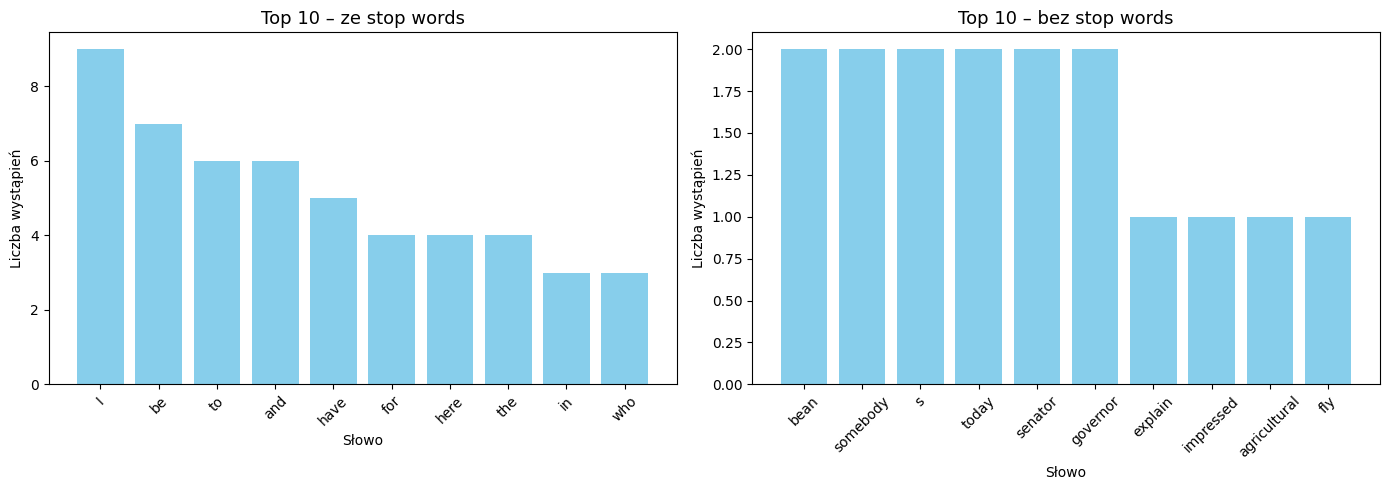

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [
    (axes[0], df_with_stop, 'Top 10 – ze stop words'),
    (axes[1], df_without_stop, 'Top 10 – bez stop words')
]:
    top = df.head(10)
    ax.bar(top['word'], top['count'], color='skyblue')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Słowo')
    ax.set_ylabel('Liczba wystąpień')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Część 6 – One-Hot Encoding

**One-Hot Encoding** przypisuje każdemu słowu wektor binarny o długości równej rozmiarowi słownika.
Tylko jedna pozycja ma wartość `1` — ta odpowiadająca danemu słowu.

### Zadanie 6.1 – Implementacja One-Hot Encoding

In [ ]:
corpus = [
    "The quick brown fox jumped over the lazy dog.",
    "She sells seashells by the seashore.",
    "Peter Piper picked a peck of pickled peppers."
]

# Krok 1: Zbuduj słownik unikalnych słów
normalized_corpus = [normalize(sentence) for sentence in corpus]

unique_words = set()
for sentence in normalized_corpus:
    unique_words.update(sentence.split())
unique_words = sorted(list(unique_words))

word_to_index = {word: i for i, word in enumerate(unique_words)}

print(f'Rozmiar słownika: {len(word_to_index)}')
print(f'Przykład mapowania: {dict(list(word_to_index.items())[:5])}')

Rozmiar słownika: 21
Przykład mapowania: {'a': 0, 'brown': 1, 'by': 2, 'dog': 3, 'fox': 4}


In [ ]:
def get_oh_encoding(tokens):
    """
    Zwraca macierz One-Hot dla listy tokenów.
    Każdy wiersz = wektor one-hot jednego tokenu.
    """
    vocab_size = len(word_to_index)
    one_hot_vectors = []

    for word in tokens:
        vector = np.zeros(vocab_size)
        idx = word_to_index.get(word)
        if idx is not None:
            vector[idx] = 1 # ustawiamy jedynkę
        one_hot_vectors.append(vector)

    return np.array(one_hot_vectors)

# Test na pierwszym zdaniu
tokens_0 = get_tokens(normalized_corpus[0])
oh_matrix = get_oh_encoding(tokens_0)

print(f'Zdanie: {corpus[0]}')
print(f'Tokeny: {tokens_0}')
print(f'Kształt macierzy One-Hot: {oh_matrix.shape}')
print(f'\nMacierz (pierwsze 5 tokenów x pierwsze 10 wymiarów):')
print(oh_matrix[:5, :10].astype(int))

Zdanie: The quick brown fox jumped over the lazy dog.
Tokeny: ['the', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'lazy', 'dog']
Kształt macierzy One-Hot: (9, 21)

Macierz (pierwsze 5 tokenów x pierwsze 10 wymiarów):
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]]


### Zadanie 6.2 – Dlaczego One-Hot ma ograniczenia?

Oblicz odległość euklidesową między wektorami słów `"fox"`, `"dog"` i `"seashore"`.
Co możesz powiedzieć o podobieństwie semantycznym na podstawie tych odległości?

In [ ]:
def get_word_vector(word):
    """Zwraca wektor one-hot dla podanego słowa."""
    vector = np.zeros(len(word_to_index))
    idx = word_to_index.get(word)
    if idx is not None:
        vector[idx] = 1
    return vector

# TODO: Oblicz odległości euklidesowe między parami słów
# np.linalg.norm(v1 - v2)

word_pairs = [("fox", "dog"), ("fox", "seashore"), ("dog", "seashore")]

for w1, w2 in word_pairs:
    v1 = get_word_vector(w1)
    v2 = get_word_vector(w2)
    dist = np.linalg.norm(v1 - v2)
    print(f'Odległość({w1!r}, {w2!r}) = {dist:.4f}')

print()
print('💭 Co te odległości mówią o podobieństwie semantycznym?')

Odległość('fox', 'dog') = 1.4142
Odległość('fox', 'seashore') = 1.4142
Odległość('dog', 'seashore') = 1.4142

💭 Co te odległości mówią o podobieństwie semantycznym?


---
## Część 7 – Bag of Words (BoW)

**Bag of Words** reprezentuje zdanie jako wektor częstości słów.
Każdy dokument staje się wektorem o długości słownika, gdzie każda wartość = liczba wystąpień słowa.

>  BoW **ignoruje kolejność słów**! "Pies gonił kota" i "Kota gonił pies" mają identyczny wektor.

### Zadanie 7.1 – BoW z CountVectorizer (sklearn)

In [ ]:
documents = [
    "I love machine learning and data science",
    "Machine learning is a subset of artificial intelligence",
    "Deep learning and neural networks are part of machine learning",
    "I love data and I love science",
]

# TODO: Użyj CountVectorizer do zbudowania macierzy BoW
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(documents)

# Wyświetl jako DataFrame
vocab = vectorizer.get_feature_names_out()
df_bow = pd.DataFrame(X_bow.toarray(), columns=vocab)
df_bow.index = [f'Doc {i+1}' for i in range(len(documents))]
print('Macierz Bag of Words:')
print(df_bow)

Macierz Bag of Words:
       and  are  artificial  data  deep  intelligence  is  learning  love  \
Doc 1    1    0           0     1     0             0   0         1     1   
Doc 2    0    0           1     0     0             1   1         1     0   
Doc 3    1    1           0     0     1             0   0         2     0   
Doc 4    1    0           0     1     0             0   0         0     2   

       machine  networks  neural  of  part  science  subset  
Doc 1        1         0       0   0     0        1       0  
Doc 2        1         0       0   1     0        0       1  
Doc 3        1         1       1   1     1        0       0  
Doc 4        0         0       0   0     0        1       0  


### Zadanie 7.2 – Problem BoW z kolejnością

Sprawdź empirycznie, że BoW traci informację o kolejności słów.

In [ ]:
sentences_order = [
    "The dog chased the cat",
    "The cat chased the dog",
    "Dog the cat the chased",  # bezsensowna kolejność
]

# TODO: Zbuduj macierz BoW i sprawdź czy wektory są identyczne
vec2 = CountVectorizer()
X2 = vec2.fit_transform(sentences_order)

df2 = pd.DataFrame(X2.toarray(), columns=vec2.get_feature_names_out())
df2.index = [f'Zdanie {i+1}' for i in range(len(sentences_order))]
print(df2)

print()
# TODO: Sprawdź czy wektory zdania 1 i 2 są identyczne (np.array_equal)
are_equal = np.array_equal(X2.toarray()[0], X2.toarray()[1])
print(f'Czy zdanie 1 i 2 mają identyczny wektor BoW? {are_equal}')

          cat  chased  dog  the
Zdanie 1    1       1    1    2
Zdanie 2    1       1    1    2
Zdanie 3    1       1    1    2

Czy zdanie 1 i 2 mają identyczny wektor BoW? True


### Zadanie 7.3 – WordCloud

Wygeneruj chmurę słów dla tekstu z przemówienia (zmienna `speech` z Części 5).
Użyj wersji **bez stop words i z lemmatyzacją**.

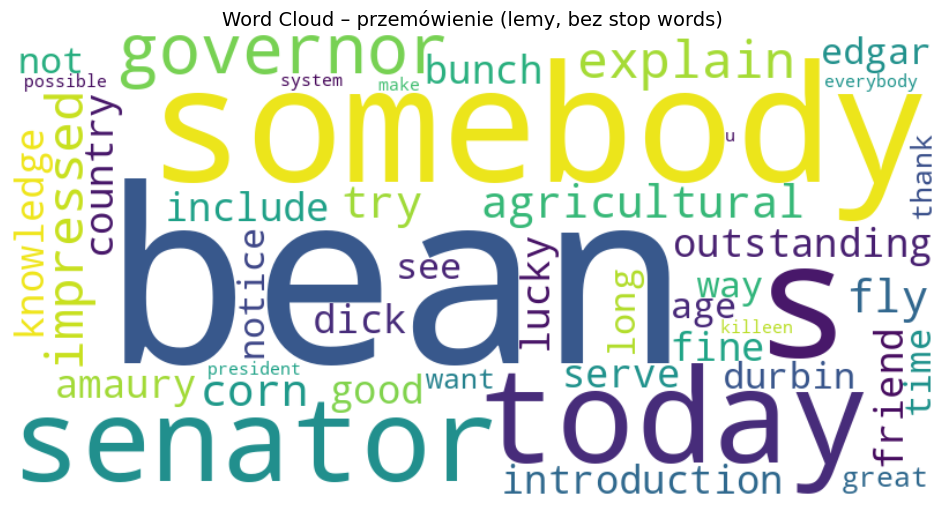

In [ ]:
# !pip install wordcloud  # odkomentuj jeśli trzeba
from wordcloud import WordCloud

# TODO:
# 1. Oblicz częstości słów (compute_freq_df z lemma=True, stop=False)
# 2. Stwórz słownik {słowo: częstość}
# 3. Wygeneruj i wyświetl WordCloud

freq_df = compute_freq_df(speech, return_lemma=True, keep_stop=False)
word_freq_dict = dict(zip(freq_df['word'], freq_df['count']))

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – przemówienie (lemy, bez stop words)', fontsize=14)
plt.show()

---
## Część 8 – TF-IDF

**TF-IDF** (Term Frequency – Inverse Document Frequency) to ważona miara:
- **TF** – jak często słowo pojawia się w dokumencie
- **IDF** – jak rzadkie jest słowo w całym korpusie

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{df(t)}\right)$$

Słowa charakterystyczne dla dokumentu (częste lokalnie, rzadkie globalnie) dostają wysoki wynik.

### Zadanie 8.1 – TF-IDF ręcznie (dla jednego słowa)

Oblicz TF-IDF dla słowa `"machine"` w dokumencie 1 korzystając ze wzoru.
Porównaj z wynikiem sklearn.

In [ ]:
import math

docs = [
    "machine learning is great",          # doc 0 – target
    "deep learning uses neural networks",  # doc 1
    "machine translation is an application of machine learning",  # doc 2
    "I love cooking and baking",           # doc 3 – niezwiązany
]

target_word = "machine"
target_doc = docs[0]

# TODO: Oblicz TF
# TF = liczba wystąpień słowa w dokumencie / całkowita liczba słów
tf = words.count(target_word) / len(words)
print(f'TF("{target_word}", doc_0) = {tf:.4f}')

# TODO: Oblicz DF (document frequency) – w ilu dokumentach wystąpuje słowo
df_word = sum(1 for doc in docs if target_word in doc.split())
print(f'DF("{target_word}") = {df_word} (z {len(docs)} dokumentów)')

# TODO: Oblicz IDF
idf = math.log(len(docs) / df_word)
print(f'IDF("{target_word}") = {idf:.4f}')

# TODO: Oblicz TF-IDF
tfidf_manual = tf * idf
print(f'TF-IDF("{target_word}", doc_0) = {tfidf_manual:.4f}')

TF("machine", doc_0) = 0.0000
DF("machine") = 2 (z 4 dokumentów)
IDF("machine") = 0.6931
TF-IDF("machine", doc_0) = 0.0000


### Zadanie 8.2 – TF-IDF z sklearn

Zastosuj `TfidfVectorizer` i porównaj wyniki z ręcznym obliczeniem.

> 💡 sklearn stosuje lekko zmodyfikowaną formułę (smooth IDF) – wyniki będą zbliżone, ale nie identyczne.

In [ ]:
# TODO: Użyj TfidfVectorizer
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(docs)

vocab_tfidf = tfidf_vec.get_feature_names_out()
df_tfidf = pd.DataFrame(X_tfidf.toarray().round(3), columns=vocab_tfidf)
df_tfidf.index = [f'Doc {i}' for i in range(len(docs))]

print('Macierz TF-IDF:')
print(df_tfidf)

print()
# TODO: Sprawdź wartość TF-IDF dla 'machine' w doc_0
sklearn_val = df_tfidf.loc['Doc 0', 'machine']
print(f'sklearn TF-IDF("machine", doc_0) = {sklearn_val:.4f}')
print(f'Ręczny TF-IDF("machine", doc_0)  = {tfidf_manual:.4f}')

Macierz TF-IDF:
          an  and  application  baking  cooking   deep  great     is  \
Doc 0  0.000  0.0        0.000     0.0      0.0  0.000  0.614  0.484   
Doc 1  0.000  0.0        0.000     0.0      0.0  0.476  0.000  0.000   
Doc 2  0.365  0.0        0.365     0.0      0.0  0.000  0.000  0.288   
Doc 3  0.000  0.5        0.000     0.5      0.5  0.000  0.000  0.000   

       learning  love  machine  networks  neural     of  translation   uses  
Doc 0     0.392   0.0    0.484     0.000   0.000  0.000        0.000  0.000  
Doc 1     0.304   0.0    0.000     0.476   0.476  0.000        0.000  0.476  
Doc 2     0.233   0.0    0.575     0.000   0.000  0.365        0.365  0.000  
Doc 3     0.000   0.5    0.000     0.000   0.000  0.000        0.000  0.000  

sklearn TF-IDF("machine", doc_0) = 0.4840
Ręczny TF-IDF("machine", doc_0)  = 0.0000


### Zadanie 8.3 – Interpretacja TF-IDF

Dla każdego dokumentu wypisz 3 słowa z najwyższym TF-IDF. Czy dobrze opisują temat dokumentu?

In [ ]:
# TODO: Dla każdego dokumentu znajdź top 3 słowa wg TF-IDF
for i, doc in enumerate(docs):
    row = df_tfidf.loc[f'Doc {i}']
    top_words = row.sort_values(ascending=False).head(3)

    print(f'Doc {i}: "{doc}"')
    print(f'  Top 3 TF-IDF: {list(top_words.items())}')
    print()

Doc 0: "machine learning is great"
  Top 3 TF-IDF: [('great', 0.614), ('is', 0.484), ('machine', 0.484)]

Doc 1: "deep learning uses neural networks"
  Top 3 TF-IDF: [('deep', 0.476), ('uses', 0.476), ('neural', 0.476)]

Doc 2: "machine translation is an application of machine learning"
  Top 3 TF-IDF: [('machine', 0.575), ('an', 0.365), ('of', 0.365)]

Doc 3: "I love cooking and baking"
  Top 3 TF-IDF: [('and', 0.5), ('baking', 0.5), ('cooking', 0.5)]



---
## Część 9 – Zadanie końcowe: pełny pipeline

Teraz złóż wszystko w jeden pipeline!

### Treść zadania:

Masz zbiór recenzji filmowych. Twoim zadaniem jest:

1. **Znormalizować** wszystkie recenzje
2. **Przetokenizować** z lemmatyzacją i bez stop words
3. Zbudować **BoW** i **TF-IDF**
4. Dla każdej recenzji wypisać **top 3 słowa kluczowe** (wg TF-IDF)
5. Narysować wykres najczęstszych słów w całym zbiorze
6. Napisać wniosek: które reprezentacje lepiej opisują treść recenzji?

In [ ]:
reviews = [
    "This movie was absolutely brilliant! The acting was superb and the storyline kept me on the edge of my seat.",
    "A terrible waste of time. The plot made no sense and the characters were completely flat and uninteresting.",
    "An amazing cinematic experience. Beautiful visuals, outstanding performances, and a deeply moving story.",
    "Disappointing film. Had high hopes but the script was weak and the pacing was far too slow throughout.",
    "Masterpiece of modern cinema. Every scene was crafted with care and the music was absolutely breathtaking.",
    "Boring and predictable. I almost fell asleep during the second act. Would not recommend to anyone.",
]

# ─────────────────────────────────────────────
# KROK 1: Normalizacja
# ─────────────────────────────────────────────
# TODO: Znormalizuj każdą recenzję
normalized_reviews = [normalize(r) for r in reviews]

print('Po normalizacji:')
for i, r in enumerate(normalized_reviews):
    print(f'  {i+1}: {r[:70]}...')

Po normalizacji:
  1: this movie was absolutely brilliant the acting was superb and the stor...
  2: a terrible waste of time the plot made no sense and the characters wer...
  3: an amazing cinematic experience beautiful visuals outstanding performa...
  4: disappointing film had high hopes but the script was weak and the paci...
  5: masterpiece of modern cinema every scene was crafted with care and the...
  6: boring and predictable i almost fell asleep during the second act woul...


In [ ]:
# ─────────────────────────────────────────────
# KROK 2: Tokenizacja z lemmatyzacją
# ─────────────────────────────────────────────
# TODO: Przetokenizuj z lemmatyzacją i bez stop words
tokenized_reviews = [get_tokens(r, return_lemma=True, keep_stop=False) for r in normalized_reviews]

print('Tokeny po lemmatyzacji (bez stop words):')
for i, tokens in enumerate(tokenized_reviews):
    print(f'  {i+1}: {tokens}')

Tokeny po lemmatyzacji (bez stop words):
  1: ['movie', 'absolutely', 'brilliant', 'acting', 'superb', 'storyline', 'keep', 'edge', 'seat']
  2: ['terrible', 'waste', 'time', 'plot', 'sense', 'character', 'completely', 'flat', 'uninteresting']
  3: ['amazing', 'cinematic', 'experience', 'beautiful', 'visual', 'outstanding', 'performance', 'deeply', 'move', 'story']
  4: ['disappointing', 'film', 'high', 'hope', 'script', 'weak', 'pacing', 'far', 'slow']
  5: ['masterpiece', 'modern', 'cinema', 'scene', 'craft', 'care', 'music', 'absolutely', 'breathtaking']
  6: ['boring', 'predictable', 'fall', 'asleep', 'second', 'act', 'recommend']


In [ ]:
# ─────────────────────────────────────────────
# KROK 3: BoW i TF-IDF
# ─────────────────────────────────────────────

# Złącz tokeny z powrotem w stringi (CountVectorizer i TfidfVectorizer oczekują stringów)
joined_reviews = [' '.join(tokens) for tokens in tokenized_reviews]

# TODO: Zbuduj macierz BoW
cv = CountVectorizer()
X_bow_final = cv.fit_transform(joined_reviews)

# TODO: Zbuduj macierz TF-IDF
tv = TfidfVectorizer()
X_tfidf_final = tv.fit_transform(joined_reviews)

print(f'Kształt macierzy BoW:   {X_bow_final.shape}')
print(f'Kształt macierzy TF-IDF: {X_tfidf_final.shape}')

Kształt macierzy BoW:   (6, 52)
Kształt macierzy TF-IDF: (6, 52)


In [ ]:
# ─────────────────────────────────────────────
# KROK 4: Top 3 słowa kluczowe per recenzja
# ─────────────────────────────────────────────

feature_names = tv.get_feature_names_out()
tfidf_array = X_tfidf_final.toarray()

print('Top 3 słowa kluczowe (TF-IDF):')
print()
for i, row in enumerate(tfidf_array):
    # TODO: Znajdź top 3 indeksy (np.argsort)
    top3_idx = np.argsort(row)[-3:][::-1]
    top3_words = [(feature_names[j], round(row[j], 3)) for j in top3_idx]
    print(f'Recenzja {i+1}: {top3_words}')
    print(f'  Treść: "{reviews[i][:60]}..."')
    print()

Top 3 słowa kluczowe (TF-IDF):

Recenzja 1: [('superb', np.float64(0.34)), ('seat', np.float64(0.34)), ('storyline', np.float64(0.34))]
  Treść: "This movie was absolutely brilliant! The acting was superb a..."

Recenzja 2: [('waste', np.float64(0.333)), ('uninteresting', np.float64(0.333)), ('terrible', np.float64(0.333))]
  Treść: "A terrible waste of time. The plot made no sense and the cha..."

Recenzja 3: [('visual', np.float64(0.316)), ('story', np.float64(0.316)), ('performance', np.float64(0.316))]
  Treść: "An amazing cinematic experience. Beautiful visuals, outstand..."

Recenzja 4: [('weak', np.float64(0.333)), ('pacing', np.float64(0.333)), ('script', np.float64(0.333))]
  Treść: "Disappointing film. Had high hopes but the script was weak a..."

Recenzja 5: [('scene', np.float64(0.34)), ('masterpiece', np.float64(0.34)), ('modern', np.float64(0.34))]
  Treść: "Masterpiece of modern cinema. Every scene was crafted with c..."

Recenzja 6: [('recommend', np.float64(0.378)), ('

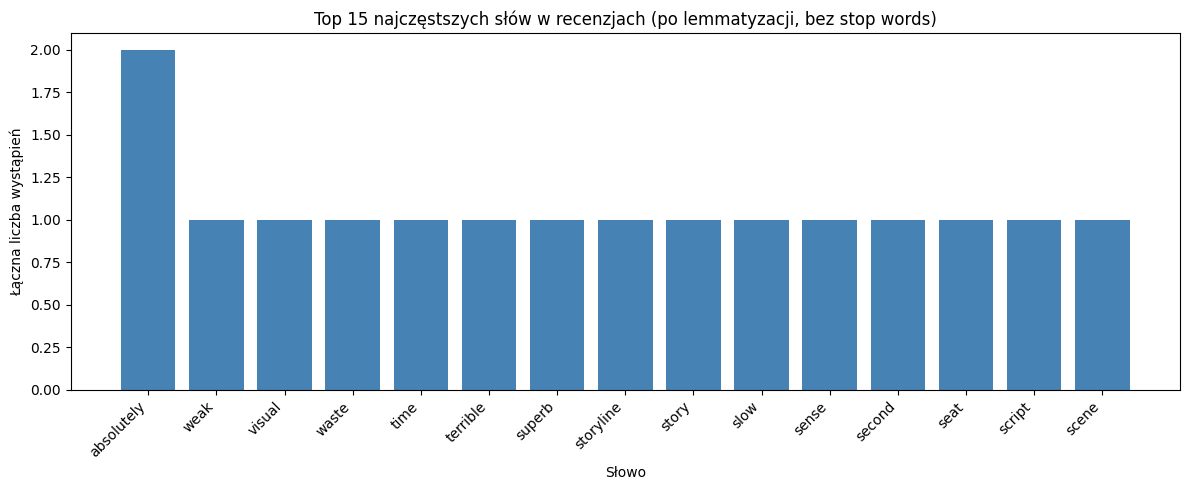

In [ ]:
# ─────────────────────────────────────────────
# KROK 5: Wizualizacja – najczęstsze słowa w całym zbiorze
# ─────────────────────────────────────────────

# TODO: Zsumuj kolumny macierzy BoW i narysuj top 15 słów
word_sums = np.asarray(X_bow_final.sum(axis=0)).flatten()
top15_idx = np.argsort(word_sums)[-15:][::-1]

plt.figure(figsize=(12, 5))
plt.bar(feature_names[top15_idx], word_sums[top15_idx], color='steelblue')
plt.title('Top 15 najczęstszych słów w recenzjach (po lemmatyzacji, bez stop words)')
plt.xlabel('Słowo')
plt.ylabel('Łączna liczba wystąpień')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Krok 6 – Wnioski

Odpowiedz na poniższe pytania:

**Wnioski:**

1. Czy słowa kluczowe wyodrębnione przez TF-IDF dobrze oddają temat każdej recenzji?
   - *Twoja odpowiedź tutaj*

2. Jaką informację traci BoW w porównaniu z oryginalnym tekstem?
   - *Twoja odpowiedź tutaj*

3. Co musiałoby się zmienić w reprezentacji, żeby model mógł odróżnić recenzję pozytywną od negatywnej?
   - *Twoja odpowiedź tutaj*

4. Dlaczego TF-IDF jest lepszy od BoW do identyfikacji słów kluczowych?
   - *Twoja odpowiedź tutaj*

---

## Podsumowanie

| Metoda | Co robi | Kiedy używać |
|--------|---------|-------------|
| `normalize()` | lowercase, usunięcie interpunkcji, normalizacja spacji | Zawsze jako pierwszy krok |
| **Stemming** | Mechaniczne obcinanie końcówek | Duże zbiory, szybkie wyszukiwanie |
| **Lemmatyzacja** | Forma słownikowa (ze słownikiem) | NLP, analiza sentymentu, chatboty |
| **Stop words** | Usuwanie słów bez znaczenia | BoW/TF-IDF; ostrożnie w sentymencie |
| **One-Hot** | Wektor binarny per słowo | Prosta klasyfikacja |
| **BoW** | Wektor częstości słów w zdaniu | Klasyfikacja tematów, spam |
| **TF-IDF** | Ważona częstość (lokalna vs globalna) | Wyszukiwanie, słowa kluczowe |

